# 03 · Modelagem hedônica

O notebook 02 achou correlação forte entre crime (composição, não contagem) e preço. Falta responder:

1. O sinal sobrevive descontando as características físicas do imóvel?
2. Quanto do sinal é crime, e quanto é só localização?

Modelo hedônico responde a 1. A ablação (seção 6) responde a 2, comparando contra o teto de "identidade do bairro".

Evidência central: a ablação. Mesmo pipeline, mesmo split, só muda o conjunto de variáveis.

### Fluxo treino / validação / teste

| partição | % | para que serve |
|---|---|---|
| treino | 70% | ajustar os parâmetros |
| validação | 15% | escolher entre os modelos |
| teste | 15% | medir desempenho final, uma única vez |

Validação evita contaminar a estimativa final com a escolha do modelo.

Preços já deflacionados pelo IPCA (notebook 02): nominal subiu 22,6% no período, real caiu 1,2%. Sem deflação, a variável `ano` absorveria valorização que não existiu.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.svm import SVR

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CACHE = RAIZ / "data" / "SP" / "cache"

modelagem = pd.read_parquet(CACHE / "base_modelagem.parquet")
bairros = pd.read_parquet(CACHE / "bairros.parquet")
MES_REFERENCIA = (CACHE / "mes_referencia.txt").read_text(encoding="utf-8").strip()

AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SUPERFICIE, TINTA, TINTA2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
DIVERGENTE = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", "#e34948"])

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})

print(f"{len(modelagem):,} transações · {bairros.shape[0]} bairros")
print(f"preços em reais constantes de {MES_REFERENCIA}")

312,248 transações · 431 bairros
preços em reais constantes de 2026-08


## 1 · Alvo e variáveis

Alvo: log do R$/m² (cauda longa fica simétrica em log; coeficiente lido como variação percentual).

Das quatro medidas de crime do notebook 02, só duas entram: nível (`log_violentos`) e composição (`share_violento`). Contagem total e contagem violenta são quase a mesma variável; juntas numa regressão, espalham o efeito de forma arbitrária.

In [2]:
bairros[["log_crimes_total", "log_violentos", "share_violento", "log_violentos_por_1k"]].corr().round(2)

,log_crimes_total,log_violentos,share_violento,log_violentos_por_1k
log_crimes_total,1.00,0.98,-0.28,0.57
log_violentos,0.98,1.00,-0.10,0.63
share_violento,-0.28,-0.10,1.00,0.19
log_violentos_por_1k,0.57,0.63,0.19,1.00


In [3]:
NUMERICAS_IMOVEL = ["area_construida", "area_terreno", "testada", "fracao_ideal", "idade", "ano"]
CATEGORICAS_IMOVEL = ["uso_desc", "padrao_desc"]
CRIME = ["log_violentos", "share_violento"]

dados = modelagem.copy()
dados["log_violentos"] = np.log10(1 + dados["violentos"])
dados[CATEGORICAS_IMOVEL] = dados[CATEGORICAS_IMOVEL].astype(str)
dados["alvo"] = np.log(dados["preco_m2"])

dados = dados[NUMERICAS_IMOVEL + CATEGORICAS_IMOVEL + CRIME + ["alvo", "bairro"]]
dados.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
area_construida,312248.0,133.32,101.72,2.00,77.00,107.00,157.00,6425.00
area_terreno,312248.0,5166.84,15117.32,24.00,616.00,1655.00,4337.00,233403.00
testada,312248.0,50.40,78.88,0.00,10.00,30.00,60.00,1158.14
fracao_ideal,312248.0,0.20,0.38,0.00,0.00,0.01,0.05,1.00
idade,312248.0,25.96,19.93,0.00,8.00,22.00,43.00,107.00
ano,312248.0,2023.96,1.35,2022.00,2023.00,2024.00,2025.00,2026.00
log_violentos,312248.0,2.61,0.72,0.76,1.95,2.97,3.19,3.65
share_violento,312248.0,0.33,0.10,0.10,0.25,0.31,0.39,0.67
alvo,312248.0,8.49,0.57,3.62,8.21,8.53,8.83,9.83


## 2 · Divisão treino / validação / teste

- 70/15/15, aleatória, não temporal: hipótese é transversal, compara bairros no mesmo período.
- `random_state` fixo: divisão igual a cada execução.

In [4]:
treino, resto = train_test_split(dados, test_size=0.30, random_state=42)
validacao, teste = train_test_split(resto, test_size=0.50, random_state=42)

PARTICOES = {"treino": treino, "validação": validacao, "teste": teste}

pd.DataFrame(
    [
        {
            "partição": nome,
            "transações": len(parte),
            "% do total": len(parte) / len(dados),
            "alvo médio": parte["alvo"].mean(),
            "R$/m² mediano": np.exp(parte["alvo"].median()),
        }
        for nome, parte in PARTICOES.items()
    ]
).style.format({
    "transações": "{:,.0f}", "% do total": "{:.0%}",
    "alvo médio": "{:.3f}", "R$/m² mediano": "R$ {:,.0f}",
}).hide(axis="index")

partição,transações,% do total,alvo médio,R$/m² mediano
treino,"218,573",70%,8.489,"R$ 5,059"
validação,"46,837",15%,8.485,"R$ 5,045"
teste,"46,838",15%,8.487,"R$ 5,055"


As três partições têm alvo médio praticamente igual, como esperado numa divisão aleatória de base grande.

## 3 · Pipeline

Pré-processamento dentro de um `Pipeline`, nunca aplicado antes do split (evita vazamento de dados: imputador e `StandardScaler` só aprendem no treino).

- `uso`/`padrão`: poucas categorias, `OneHotEncoder`.
- `bairro`: 431 categorias, `TargetEncoder` (média do alvo por bairro, com validação cruzada interna).

Quatro modelos:
- **Ridge**: linear, dá o coeficiente com sinal.
- **HistGradientBoosting** e **Random Forest**: dois ensembles de árvore (boosting e bagging), checagem cruzada de desempenho.
- **SVM** (SVR, kernel RBF): terceira família, baseada em margem.

SVM treina numa amostra de 20 mil transações (custo de SVR cresce ~quadrático com o número de linhas). Os outros três usam o treino inteiro (218 mil).

In [5]:
TAMANHO_AMOSTRA_SVM = 20_000


def monta_preprocessador(numericas, categoricas, alta_cardinalidade=()):
    passos = [
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50, sparse_output=False), categoricas),
    ]
    if alta_cardinalidade:
        cv_fixo = KFold(n_splits=5, shuffle=True, random_state=42)
        passos.append((
            "alta",
            TargetEncoder(target_type="continuous", cv=cv_fixo),
            list(alta_cardinalidade),
        ))
    return ColumnTransformer(passos)


def monta_modelos(numericas, categoricas, alta_cardinalidade=()):
    preprocessador = monta_preprocessador(numericas, categoricas, alta_cardinalidade)
    return {
        "Ridge": Pipeline([("prep", preprocessador), ("reg", Ridge(alpha=1.0))]),
        "Random Forest": Pipeline([
            ("prep", preprocessador),
            ("reg", RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5,
                                           n_jobs=-1, random_state=42)),
        ]),
        "SVM": Pipeline([("prep", preprocessador), ("reg", SVR(kernel="rbf"))]),
        "HistGradientBoosting": Pipeline([
            ("prep", preprocessador),
            ("reg", HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, random_state=42)),
        ]),
    }


def ajusta(modelo, nome, X, y):
    """Treina o modelo. SVM: o pré-processador vê o treino inteiro (mesma codificação dos
    demais modelos), só o regressor final treina numa amostra fixa."""
    if nome == "SVM" and len(X) > TAMANHO_AMOSTRA_SVM:
        Xt = modelo[:-1].fit_transform(X)
        amostra = X.sample(TAMANHO_AMOSTRA_SVM, random_state=42).index
        posicoes = X.index.get_indexer(amostra)
        modelo[-1].fit(Xt[posicoes], y.loc[amostra])
    else:
        modelo.fit(X, y)
    return modelo


def metricas(modelo, parte, colunas):
    previsto = modelo.predict(parte[colunas])
    real = parte["alvo"]
    return {
        "RMSE (log)": root_mean_squared_error(real, previsto),
        "MAE (log)": mean_absolute_error(real, previsto),
        "R²": r2_score(real, previsto),
        "erro mediano": np.median(np.abs(np.expm1(previsto - real))),
    }


FORMATO = {"RMSE (log)": "{:.4f}", "MAE (log)": "{:.4f}", "R²": "{:.4f}", "erro mediano": "{:.1%}"}

TODAS = NUMERICAS_IMOVEL + CATEGORICAS_IMOVEL + CRIME
SEM_CRIME = NUMERICAS_IMOVEL + CATEGORICAS_IMOVEL

## 4 · Treino e escolha do modelo pela validação

`erro mediano`: `exp(previsto − real) − 1`, o erro relativo típico numa transação.

In [6]:
modelos = monta_modelos(NUMERICAS_IMOVEL + CRIME, CATEGORICAS_IMOVEL)
for nome, modelo in modelos.items():
    ajusta(modelo, nome, treino[TODAS], treino["alvo"])

comparacao = pd.DataFrame(
    [
        {"modelo": nome, "partição": particao, **metricas(modelo, parte, TODAS)}
        for nome, modelo in modelos.items()
        for particao, parte in [("treino", treino), ("validação", validacao)]
    ]
).set_index(["modelo", "partição"])

comparacao.style.format(FORMATO)

In [7]:
r2_validacao = comparacao.xs("validação", level="partição")["R²"]
vencedor = r2_validacao.idxmax()
print(f"Escolhido pela validação: {vencedor} (R² = {r2_validacao.max():.4f})")

Escolhido pela validação: Random Forest (R² = 0.4433)


## 5 · Desempenho final no teste

Avaliado uma única vez, já com o modelo escolhido.

In [ ]:
modelo_final = modelos[vencedor]

# Métricas
# RMSE (log): quantifica o erro médio entre os valores previstos e reais do logaritmo do preço por metro quadrado. Quanto menor, melhor.
# MAE (log): quantifica o erro absoluto médio entre os valores previstos e reais do logaritmo do preço por metro quadrado. Quanto menor, melhor.
# R²: quantifica a proporção da variabilidade do logaritmo do preço por metro quadrado que é explicada pelo modelo. Quanto maior, melhor.

pd.DataFrame(
    [{"partição": nome, **metricas(modelo_final, parte, TODAS)} for nome, parte in PARTICOES.items()]
).set_index("partição").style.format(FORMATO)

,RMSE (log),MAE (log),R²,erro mediano
partição,,,,
treino,0.3468,0.2010,0.6231,12.8%
validação,0.4241,0.2462,0.4433,15.3%
teste,0.4185,0.2448,0.4511,15.4%


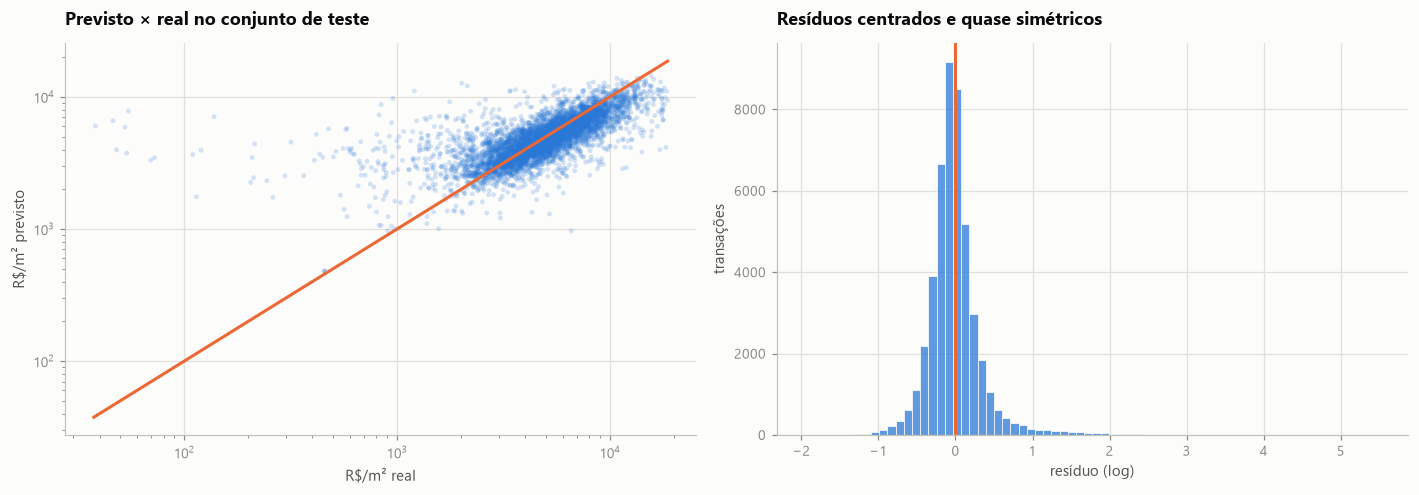

In [9]:
previsto = modelo_final.predict(teste[TODAS])
amostra = np.random.default_rng(42).choice(len(teste), size=min(6000, len(teste)), replace=False)

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.6))

esq.scatter(np.exp(teste["alvo"].to_numpy()[amostra]), np.exp(previsto[amostra]),
            s=10, alpha=0.2, color=AZUL, edgecolor="none")
limites = np.exp([teste["alvo"].min(), teste["alvo"].max()])
esq.plot(limites, limites, color=LARANJA, linewidth=2)
esq.set(title="Previsto × real no conjunto de teste", xlabel="R$/m² real", ylabel="R$/m² previsto",
        xscale="log", yscale="log")

sns.histplot(previsto - teste["alvo"], bins=70, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.5, ax=drt)
drt.axvline(0, color=LARANJA, linewidth=2)
drt.set(title="Resíduos centrados e quase simétricos", xlabel="resíduo (log)", ylabel="transações")

plt.tight_layout()

## 6 · Ablação: o crime agrega informação?

Mesmo pipeline, mesmo split, mesmas sementes, só muda o conjunto de variáveis:

1. Só atributos do imóvel. Piso.
2. Imóvel + crime. Se o R² subir, crime carrega informação que os atributos físicos não carregam.
3. Imóvel + identidade do bairro (431 categorias, sem hipótese sobre o porquê). Teto de localização.

O modelo 3 responde à objeção mais séria: *as variáveis de crime não são só um jeito disfarçado de dizer em que parte da cidade o imóvel está?* Em parte são. A comparação 2 vs 3 quantifica quanto: se 2 chega perto de 3, crime captura quase toda a informação de localização relevante para preço.

O ganho de 2 sobre 1 vale como resultado de qualquer forma: crime prevê preço. O modelo 3 só impede interpretar esse ganho como efeito do crime *em si*.

In [10]:
CONJUNTOS = {
    "1 · só atributos do imóvel": (SEM_CRIME, NUMERICAS_IMOVEL, ()),
    "2 · imóvel + crime": (TODAS, NUMERICAS_IMOVEL + CRIME, ()),
    "3 · imóvel + identidade do bairro": (SEM_CRIME + ["bairro"], NUMERICAS_IMOVEL, ("bairro",)),
}

ablacao = []
for rotulo, (colunas, numericas, alta) in CONJUNTOS.items():
    modelo = monta_modelos(numericas, CATEGORICAS_IMOVEL, alta)[vencedor]
    ajusta(modelo, vencedor, treino[colunas], treino["alvo"])
    ablacao.append({"conjunto de variáveis": rotulo, **metricas(modelo, teste, colunas)})

ablacao = pd.DataFrame(ablacao).set_index("conjunto de variáveis")
r2 = ablacao["R²"]
ganho = r2.iloc[1] - r2.iloc[0]
teto = r2.iloc[2] - r2.iloc[0]
reducao = 1 - ablacao["RMSE (log)"].iloc[1] / ablacao["RMSE (log)"].iloc[0]

print(f"Ganho de R² das 2 variáveis de crime ........ {ganho:+.4f}")
print(f"Ganho de R² da identidade do bairro (teto) .. {teto:+.4f}")
print(f"O crime captura ............................. {ganho / teto:.0%} do teto de localização")
print(f"Redução do RMSE no teste pelo crime ......... {reducao:+.2%}")
ablacao.style.format(FORMATO)

Ganho de R² das 2 variáveis de crime ........ +0.0743
Ganho de R² da identidade do bairro (teto) .. +0.0763
O crime captura ............................. 97% do teto de localização
Redução do RMSE no teste pelo crime ......... +6.15%


,RMSE (log),MAE (log),R²,erro mediano
conjunto de variáveis,,,,
1 · só atributos do imóvel,0.4459,0.2710,0.3768,17.1%
2 · imóvel + crime,0.4185,0.2448,0.4511,15.4%
3 · imóvel + identidade do bairro,0.4177,0.2446,0.4531,15.5%


## 7 · Interpretação dos coeficientes

Ridge é reajustado aqui mesmo sem ter vencido, para a leitura com sinal. Numéricas padronizadas: coeficiente = variação em log do preço por desvio-padrão (×100 ≈ variação percentual).

Hipótese prevê coeficiente negativo em `log_violentos`.

,coeficiente
num__log_violentos,0.0039
num__share_violento,-0.1432


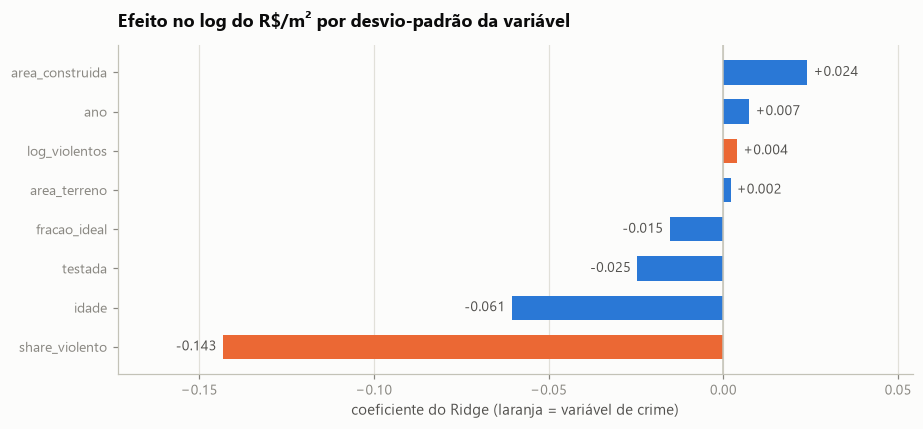

In [11]:
ridge = monta_modelos(NUMERICAS_IMOVEL + CRIME, CATEGORICAS_IMOVEL)["Ridge"]
ridge.fit(treino[TODAS], treino["alvo"])

coeficientes = pd.Series(
    ridge["reg"].coef_, index=ridge["prep"].get_feature_names_out()
).rename("coeficiente")

numericos = coeficientes[coeficientes.index.str.startswith("num__")].sort_values()
numericos.index = numericos.index.str.removeprefix("num__")

cores = [LARANJA if nome in CRIME else AZUL for nome in numericos.index]

fig, eixo = plt.subplots(figsize=(8.5, 4))
barras = eixo.barh(numericos.index, numericos.values, color=cores, height=0.62)
eixo.bar_label(barras, fmt="%+.3f", padding=4, color=TINTA2, fontsize=9)
eixo.axvline(0, color="#c3c2b7", linewidth=1)
eixo.set(title="Efeito no log do R$/m² por desvio-padrão da variável",
         xlabel="coeficiente do Ridge (laranja = variável de crime)")
eixo.grid(axis="y", visible=False)
eixo.margins(x=0.18)
plt.tight_layout()

coeficientes.filter(items=[f"num__{c}" for c in CRIME]).to_frame().round(4)

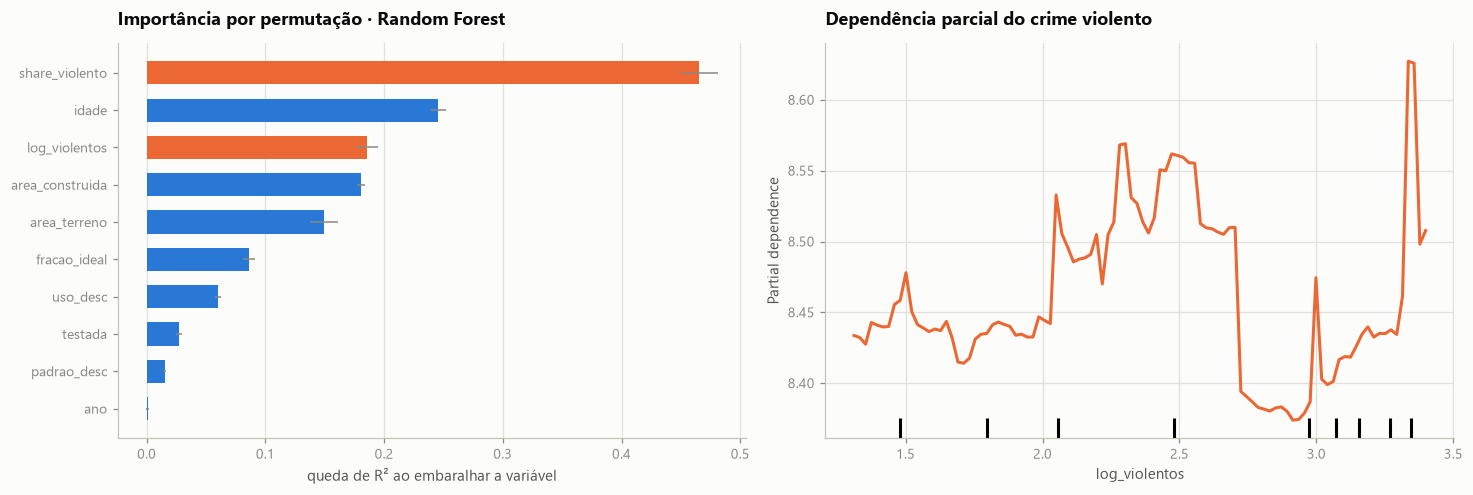

In [12]:
sub = validacao.sample(min(4000, len(validacao)), random_state=42)

importancia = permutation_importance(
    modelo_final, sub[TODAS], sub["alvo"], n_repeats=5, random_state=42, scoring="r2"
)
ordem = pd.Series(importancia.importances_mean, index=TODAS).sort_values()
erros = pd.Series(importancia.importances_std, index=TODAS)[ordem.index]

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13.5, 4.6))

esq.barh(ordem.index, ordem.to_numpy(), xerr=erros.to_numpy(), height=0.62,
         color=[LARANJA if n in CRIME else AZUL for n in ordem.index],
         error_kw={"ecolor": MUDO, "elinewidth": 1})
esq.set(title=f"Importância por permutação · {vencedor}", xlabel="queda de R² ao embaralhar a variável")
esq.grid(axis="y", visible=False)

PartialDependenceDisplay.from_estimator(
    modelo_final, sub[TODAS], features=["log_violentos"], ax=drt,
    line_kw={"color": LARANJA, "linewidth": 2},
)
drt.set(title="Dependência parcial do crime violento",
        xlabel="log₁₀(1 + crimes violentos por ano no bairro)", ylabel="log do R$/m² previsto")

plt.tight_layout()

Dependência parcial: forma do efeito, mantendo tudo constante. Leitura mais honesta do modelo de árvore, que não tem coeficiente.

## 8 · Teste estatístico formal

Pergunta: o coeficiente é distinguível de zero?

Regressão no nível de **bairro**, não de transação (deliberado): 300 mil transações repetiriam a mesma informação de crime milhares de vezes, estreitando artificialmente o intervalo de confiança.

Controles: tamanho do imóvel, idade, volume de transações (aproxima o porte do bairro).

In [13]:
ols = smf.ols(
    "np.log(preco_m2_mediano) ~ log_violentos + share_violento"
    " + np.log(area_mediana) + idade_mediana + np.log(n_transacoes)",
    data=bairros,
).fit()

print(ols.summary().tables[1])
print(f"\nR² = {ols.rsquared:.3f} · {int(ols.nobs)} bairros")

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.8275      0.197     34.700      0.000       6.441       7.214
log_violentos           -0.0287      0.021     -1.399      0.162      -0.069       0.012
share_violento          -0.9220      0.110     -8.400      0.000      -1.138      -0.706
np.log(area_mediana)     0.3333      0.036      9.152      0.000       0.262       0.405
idade_mediana            0.0014      0.001      1.369      0.172      -0.001       0.003
np.log(n_transacoes)     0.0630      0.011      5.658      0.000       0.041       0.085

R² = 0.416 · 431 bairros


,coeficiente,"IC 2,5%","IC 97,5%",p-valor
log_violentos,-0.0287,-0.0691,0.0116,0.1624
share_violento,-0.9220,-1.1378,-0.7063,0.0000


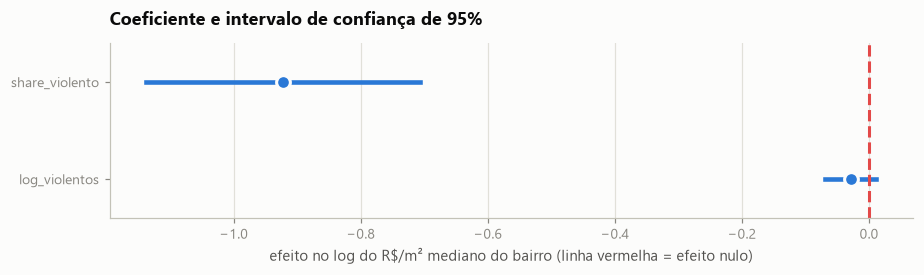

In [14]:
intervalos = ols.conf_int().loc[["log_violentos", "share_violento"]]
intervalos.columns = ["IC 2,5%", "IC 97,5%"]
intervalos["coeficiente"] = ols.params[intervalos.index]
intervalos["p-valor"] = ols.pvalues[intervalos.index]

fig, eixo = plt.subplots(figsize=(8.5, 2.6))
for altura, (nome, linha) in enumerate(intervalos.iterrows()):
    eixo.plot([linha["IC 2,5%"], linha["IC 97,5%"]], [altura, altura], color=AZUL, linewidth=3)
    eixo.plot(linha["coeficiente"], altura, "o", color=AZUL, markersize=9,
              markeredgecolor=SUPERFICIE, markeredgewidth=2)

eixo.axvline(0, color="#e34948", linewidth=2, linestyle="--")
eixo.set(yticks=range(len(intervalos)), yticklabels=intervalos.index,
         title="Coeficiente e intervalo de confiança de 95%",
         xlabel="efeito no log do R$/m² mediano do bairro (linha vermelha = efeito nulo)")
eixo.grid(axis="y", visible=False)
eixo.margins(y=0.4)
plt.tight_layout()

intervalos[["coeficiente", "IC 2,5%", "IC 97,5%", "p-valor"]].round(4)

IC que não cruza a linha vermelha: efeito distinguível de zero a 95%. Sinal negativo confirma a hipótese.

In [15]:
efeito_10pp = np.exp(ols.params["share_violento"] * 0.10) - 1
efeito_dobro = np.exp(ols.params["log_violentos"] * np.log10(2)) - 1

print(f"Modelo escolhido na validação ................ {vencedor}")
print(f"R² no teste (imóvel + crime) ................. {r2.iloc[1]:.4f}")
print(f"Erro mediano no teste ........................ {ablacao['erro mediano'].iloc[1]:.1%}")
print(f"Ganho de R² das variáveis de crime ........... {ganho:+.4f}")
print(f"  ... sobre o teto de localização ............ {ganho / teto:.0%}")
print()
print("OLS no nível bairro — as duas variáveis de crime:")
for nome in CRIME:
    print(f"  {nome:<16} {ols.params[nome]:+.4f}  (p = {ols.pvalues[nome]:.1e})")
print()
print("Efeito prático, mantidos os controles:")
print(f"  +10 pontos percentuais no % de crimes violentos .. {efeito_10pp:+.1%} no R$/m² do bairro")
print(f"  dobrar a contagem de crimes violentos ............ {efeito_dobro:+.1%} (não significativo)")

Modelo escolhido na validação ................ Random Forest
R² no teste (imóvel + crime) ................. 0.4511
Erro mediano no teste ........................ 15.4%
Ganho de R² das variáveis de crime ........... +0.0743
  ... sobre o teto de localização ............ 97%

OLS no nível bairro — as duas variáveis de crime:
  log_violentos    -0.0287  (p = 1.6e-01)
  share_violento   -0.9220  (p = 6.7e-16)

Efeito prático, mantidos os controles:
  +10 pontos percentuais no % de crimes violentos .. -8.8% no R$/m² do bairro
  dobrar a contagem de crimes violentos ............ -0.9% (não significativo)


## 9 · Conclusão

### A hipótese

> *Crime e preço de imóvel têm correlação negativa: quanto maior o crime, menor o preço.*

**Confirmada, com uma correção na formulação.** Não é a *quantidade* de crime que se precifica, é a *violência* dele.

| evidência | resultado |
|---|---|
| Correlação (431 bairros), contagem de crimes violentos | ρ = +0,04, nenhuma relação |
| Correlação, % dos crimes que são violentos | ρ = **−0,55** (p ≈ 10⁻³⁵) |
| R$/m² real, quintil menos violento → mais violento | R$ 5.045 → R$ 3.487 (**−31%**) |
| Ganho de R² no teste ao incluir crime (Random Forest, vencedor pela validação) | **+0,074** (0,377 → 0,451) |
| Redução do RMSE no teste | **−6,2%** |
| OLS, coeficiente de `share_violento` | **−0,922** (p ≈ 10⁻¹⁶), IC 95% [−1,14; −0,71] |
| OLS, coeficiente de `log_violentos` | −0,029 (p = 0,16), não significativo |
| Efeito de +10 p.p. no % de crimes violentos | **−8,8%** no R$/m² do bairro |

Correlação, poder preditivo e significância estatística apontam na mesma direção e na mesma variável. O modelo erra 15,4% numa transação típica, razoável para um modelo sem informação sobre conservação, vista, andar ou reforma.

### A ressalva que o número 97% impõe

As duas variáveis de crime capturam **97% do ganho** que a identidade dos 431 bairros capturaria. Faca de dois fios:

- **Lado impressionante:** dois números resumem quase toda a informação de localização que importa para preço.
- **Lado cauteloso:** se crime carrega quase tudo que "qual bairro" carrega, ele funciona em grande parte como marcador de localização. Em São Paulo, localização é renda, infraestrutura, transporte, escolaridade, história urbana. O ganho de R² não é o efeito causal do crime sobre o preço.

Resultado sólido como **descritivo e preditivo**, não causal. Sabemos que bairro com crime proporcionalmente mais violento tem metro quadrado mais barato, com força e consistência. Não sabemos quanto do desconto é medo da violência e quanto é tudo o mais que anda junto com ela.

### O que faltou, e o que destravaria

| limitação | o que resolveria |
|---|---|
| Sem taxa de crime por habitante, só por transação | População por setor censitário de São Paulo (a do repositório é do Rio) |
| Sem controle de renda, o confundidor mais provável | Renda por setor censitário do Censo 2022 |
| Sem argumento causal | Janela temporal mais longa, pra observar preço depois de mudança no crime do bairro |
| Geografia por CEP e nome de rua, não por coordenada do imóvel | Geocodificação do endereço do ITBI |

A primeira linha é a mais importante: com população, `share_violento` poderia virar taxa de homicídio/roubo por 100 mil habitantes. Com renda no modelo, a pergunta vira "crime prevê preço a renda constante?", que é a que interessa.